<a href="https://colab.research.google.com/github/deartoms/python/blob/main/SubWay_traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving NanumGothic.ttf to NanumGothic (1).ttf


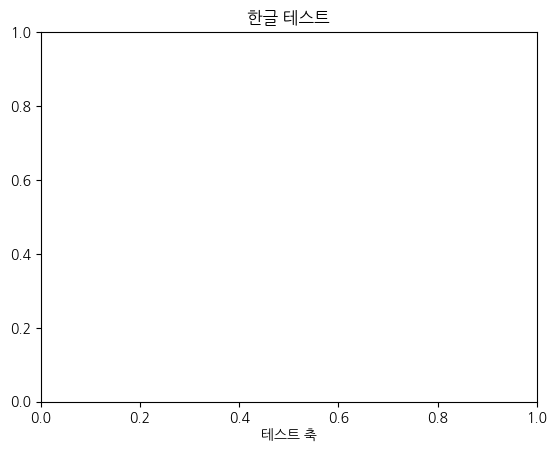

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests # API 데이터 요청
import xml.etree.ElementTree as ET #xml로 가져오기
import warnings # 코드 실행시 불필요한 경고 메세지 숨김
import pprint
import os
from scipy import stats
from scipy.stats import skew
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
#XML방식
api_key = '7479756c467a6c6637377378425967'
start=1 #시작 행 번호
end=1000 #끝 행 번호

all_data = []

for year in range(2023, 2026):  # 2023 ~ 2025
  for month in range(1, 13):
      yyyymm = f'{year}{month:02d}' # 02d : 한 자리 숫자를 두 자리로 변환(1 -> 01 9 -> 09)

      url = (f'http://openapi.seoul.go.kr:8088/{api_key}/xml'
            f'/CardSubwayTime/{start}/{end}/{yyyymm}/2호선')

      response = requests.get(url, timeout=10) # API 호출 timeout -> 10초 안에 응답 없으면 종료
      root = ET.fromstring(response.content) # XML-> 트리형 구조로 변환

      rows = [
          {child.tag: child.text for child in row}
          for row in root.findall('.//row') # XML에서 row 모두 찾기
      ]

      all_data.extend(rows) # 월별 데이터를 불러온걸 쭉 붙임

df = pd.DataFrame(all_data)

# 5개 역 필터
stations = ['홍대입구', '잠실(송파구청)', '성수', '동대문역사문화공원(DDP)', '강남']
df_5 = df[df['STTN'].isin(stations)].copy() # .isin(stations) : 해당 값이 있으면 True

pd.set_option('display.max_columns', None) # 숨어있는 컬럼도 다 보임

# 작업 일자 삭제해버리기
df_5 = df_5.drop(columns=['JOB_YMD'])

df

,USE_MM,SBWY_ROUT_LN_NM,STTN,HR_4_GET_ON_NOPE,HR_4_GET_OFF_NOPE,HR_5_GET_ON_NOPE,HR_5_GET_OFF_NOPE,HR_6_GET_ON_NOPE,HR_6_GET_OFF_NOPE,HR_7_GET_ON_NOPE,HR_7_GET_OFF_NOPE,HR_8_GET_ON_NOPE,HR_8_GET_OFF_NOPE,HR_9_GET_ON_NOPE,HR_9_GET_OFF_NOPE,HR_10_GET_ON_NOPE,HR_10_GET_OFF_NOPE,HR_11_GET_ON_NOPE,HR_11_GET_OFF_NOPE,HR_12_GET_ON_NOPE,HR_12_GET_OFF_NOPE,HR_13_GET_ON_NOPE,HR_13_GET_OFF_NOPE,HR_14_GET_ON_NOPE,HR_14_GET_OFF_NOPE,HR_15_GET_ON_NOPE,HR_15_GET_OFF_NOPE,HR_16_GET_ON_NOPE,HR_16_GET_OFF_NOPE,HR_17_GET_ON_NOPE,HR_17_GET_OFF_NOPE,HR_18_GET_ON_NOPE,HR_18_GET_OFF_NOPE,HR_19_GET_ON_NOPE,HR_19_GET_OFF_NOPE,HR_20_GET_ON_NOPE,HR_20_GET_OFF_NOPE,HR_21_GET_ON_NOPE,HR_21_GET_OFF_NOPE,HR_22_GET_ON_NOPE,HR_22_GET_OFF_NOPE,HR_23_GET_ON_NOPE,HR_23_GET_OFF_NOPE,HR_0_GET_ON_NOPE,HR_0_GET_OFF_NOPE,HR_1_GET_ON_NOPE,HR_1_GET_OFF_NOPE,HR_2_GET_ON_NOPE,HR_2_GET_OFF_NOPE,HR_3_GET_ON_NOPE,HR_3_GET_OFF_NOPE,JOB_YMD
0,202301,2호선,시청,79,3,925,1567,1831,14370,4912,60954,7102,208659,9423,84331,13267,26275,19837,23660,20585,23002,24517,24233,30087,22884,36032,21018,43267,18443,88932,19758,161892,20035,54353,10646,41819,6917,40026,6902,24971,5513,10048,3581,1330,1242,11,84,1,4,0,0,20230203
1,202301,2호선,을지로입구,55,0,2175,2658,3349,23095,9165,118205,14575,320362,18074,153832,23678,68249,34450,61819,39880,54768,48851,54487,57229,49936,70085,47262,82143,48579,146331,55314,267439,57451,116737,33351,105198,21485,74543,19242,56381,15749,21616,8956,3116,3627,18,676,0,9,0,0,20230203
2,202301,2호선,을지로3가,25,1,970,1583,2242,18430,5271,66187,9982,173069,11760,71074,15005,30477,19421,25760,21070,23356,23841,26525,28433,23869,33578,22390,40422,24156,82297,28767,133476,33250,52650,19807,38649,11273,42595,9787,35141,8229,20185,5347,3123,1434,28,100,0,0,0,0,20230203
3,202301,2호선,을지로4가,12,1,770,1085,1753,11422,4109,29627,7826,74788,8709,37557,10959,22793,14988,22383,16300,20445,18651,20646,21868,19000,24936,16848,30100,15040,53352,14497,63911,14675,26694,9243,15321,6290,12542,6294,9061,5776,4218,3776,725,1246,3,41,0,0,0,0,20230203
4,202301,2호선,동대문역사문화공원(DDP),261,5,4347,1165,3500,6976,6027,16018,10678,41478,10496,27697,11600,24262,14704,25763,18376,25136,19560,26506,23331,27221,27462,24666,31730,23152,39235,24524,42810,27366,25618,24160,19510,16571,20538,14460,14806,12389,7089,8045,1444,2762,11,184,0,2,0,0,20230203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,202512,2호선,신설동,62,4,1164,339,1677,2138,4928,5707,9824,13452,6235,9677,5953,8742,6671,7966,7860,8212,8291,7987,9234,7090,9926,6395,10755,6017,12730,6490,12952,7978,5391,6558,3307,4986,3112,4422,1866,4277,861,2762,138,1163,12,274,0,19,0,0,20260103
1796,202512,2호선,도림천,0,0,433,345,1471,839,3762,3662,3752,6108,2669,2207,2553,1447,1924,1546,2218,1864,1997,2329,2829,2132,2523,1743,2986,2392,3656,2694,3642,3656,1600,2710,979,2110,833,1859,460,1375,213,1136,60,393,1,19,0,0,0,0,20260103
1797,202512,2호선,양천구청,26,0,4925,804,12088,2442,32643,5180,30651,9634,17830,5265,13545,4396,11801,5654,11940,7698,10914,9102,9067,9971,9167,12894,10365,16408,10516,21395,9559,29951,4441,23545,3321,15554,2650,14834,2212,12362,790,9039,227,2678,3,81,0,0,0,0,20260103
1798,202512,2호선,신정네거리,120,3,8448,766,18508,2356,51052,4222,47448,11904,25460,8833,19495,8357,18310,9390,17927,11575,16046,13324,14118,14617,14236,19141,15144,24460,14595,33602,12618,48405,7576,35205,5731,22361,4833,20219,3750,18279,1692,12140,355,3484,2,226,0,0,0,0,20260103


In [ ]:
df_5.info() # daretime 컬럼, 결측치, 수치형, 문자형 컬럼 구분

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 4 to 1788
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   USE_MM              180 non-null    object
 1   SBWY_ROUT_LN_NM     180 non-null    object
 2   STTN                180 non-null    object
 3   HR_4_GET_ON_NOPE    180 non-null    object
 4   HR_4_GET_OFF_NOPE   180 non-null    object
 5   HR_5_GET_ON_NOPE    180 non-null    object
 6   HR_5_GET_OFF_NOPE   180 non-null    object
 7   HR_6_GET_ON_NOPE    180 non-null    object
 8   HR_6_GET_OFF_NOPE   180 non-null    object
 9   HR_7_GET_ON_NOPE    180 non-null    object
 10  HR_7_GET_OFF_NOPE   180 non-null    object
 11  HR_8_GET_ON_NOPE    180 non-null    object
 12  HR_8_GET_OFF_NOPE   180 non-null    object
 13  HR_9_GET_ON_NOPE    180 non-null    object
 14  HR_9_GET_OFF_NOPE   180 non-null    object
 15  HR_10_GET_ON_NOPE   180 non-null    object
 16  HR_10_GET_OFF_NOPE  180 non-nu

In [ ]:
# 숫자 변환 + 결측치 처리
exclude_cols = ['STTN', 'SBWY_ROUT_LN_NM', 'USE_MM']
num_cols = [col for col in df_5.columns if col not in exclude_cols]
df_5[num_cols] = df_5[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# 시간대 컬럼 묶기
time_groups = {
    'early_morning': [4],
    'morning': list(range(5, 9)),
    'day': list(range(9, 17)),
    'evening': list(range(17, 21)),
    'night': list(range(21, 24))
}

# 파생변수 생성
for name, hours in time_groups.items():
    on_cols = [f'HR_{h}_GET_ON_NOPE' for h in hours]
    off_cols = [f'HR_{h}_GET_OFF_NOPE' for h in hours]

    df_5[f'{name}_on'] = df_5[on_cols].sum(axis=1)
    df_5[f'{name}_off'] = df_5[off_cols].sum(axis=1)

# 전체 승차/하차 합계
on_sum_cols = [f'{name}_on' for name in time_groups.keys()]
off_sum_cols = [f'{name}_off' for name in time_groups.keys()]

df_5['total_on'] = df_5[on_sum_cols].sum(axis=1)
df_5['total_off'] = df_5[off_sum_cols].sum(axis=1)

# 로그 변수
for col in on_sum_cols + off_sum_cols + ['total_on', 'total_off']:
    df_5[f'{col}_log'] = np.log1p(df_5[col])

# 원본 시간 컬럼 삭제
cols_to_drop = [col for col in df_5.columns if col.startswith('HR_')]
df_5 = df_5.drop(columns=cols_to_drop)
df_5 = df_5.reset_index(drop=True) # 행 번호 다시 정렬

df_5


,USE_MM,SBWY_ROUT_LN_NM,STTN,early_morning_on,early_morning_off,morning_on,morning_off,day_on,day_off,evening_on,evening_off,night_on,night_off,total_on,total_off,early_morning_on_log,morning_on_log,day_on_log,evening_on_log,night_on_log,early_morning_off_log,morning_off_log,day_off_log,evening_off_log,night_off_log,total_on_log,total_off_log
0,202301,2호선,동대문역사문화공원(DDP),261,5,24552,65637,157259,204403,127173,92621,42433,34894,351678,397560,5.568345,10.108589,11.965656,11.753312,10.655705,1.791759,11.091910,12.227854,11.436282,10.460099,12.770474,12.893104
1,202301,2호선,성수,31,1,61853,359330,286329,537952,539253,178086,140883,38488,1028349,1113857,3.465736,11.032532,12.564900,13.197942,11.855692,0.693147,12.791999,13.195526,12.090027,10.558128,13.843466,13.923340
2,202301,2호선,잠실(송파구청),57,5,311475,271445,819059,990468,734886,622525,262640,204425,2128117,2088868,4.060443,12.649078,13.615913,13.507472,12.478543,1.791759,12.511519,13.805934,13.341541,12.227961,14.570749,14.552133
3,202301,2호선,강남,245,21,121381,470991,742707,1083719,894094,476770,443295,103351,2201722,2134852,5.505332,11.706698,13.518058,13.703567,13.001993,3.091042,13.062596,13.895910,13.074792,11.545896,14.604751,14.573908
4,202301,2호선,홍대입구,1350,43,190179,146254,591838,1028907,643543,623710,442580,161801,1869490,1960715,7.208600,12.155726,13.290990,13.374746,13.000379,3.784190,11.893107,13.844009,13.343442,11.994129,14.441177,14.488820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,202512,2호선,동대문역사문화공원(DDP),205,6,28977,79583,234382,280856,170145,157073,60751,66035,494460,583553,5.327876,10.274292,12.364712,12.044412,11.014555,1.945910,11.284568,12.545601,11.964472,11.097955,13.111224,13.276892
176,202512,2호선,성수,41,0,62393,391372,606611,1182498,900196,317282,251878,50883,1821119,1942035,3.737670,11.041224,13.315645,13.710369,12.436704,0.000000,12.877416,13.983141,12.667549,10.837304,14.414962,14.479247
177,202512,2호선,잠실(송파구청),101,3,354062,299950,1110079,1369442,942382,813423,387253,266735,2793877,2749553,4.624973,12.777230,13.919943,13.756167,12.866836,1.386294,12.611374,14.129915,13.609008,12.494015,14.842941,14.826949
178,202512,2호선,강남,187,7,132100,551166,898307,1242781,1024820,560760,470740,132361,2526154,2487075,5.236442,11.791322,13.708268,13.840029,13.062063,2.079442,13.219793,14.032863,13.237050,11.793296,14.742209,14.726618


In [ ]:
# 트렌드 피처 추가
# 모델어 '2012년은 수요가 더 높다'는 성장 트렌드를 못 학습하면 테스트셋을 지속적으로 과소 예측하게 됨
# 서비스 시작 시점(2011년 1월)부터 몇 번째 달인지를 나타내는 연속형 숫자
# -> '시간이 지날수록 수요가 선형적으로 증가'하는 트렌드를 표현

# month_index (경과 월 수)
# 2011년 1월 -> month_index = 1
# 2012년 1월 -> month_index = 13
# year (범주형)와의 차이: year는 2011, 2012 두 값만 각 연도의 평균 수준만 학습
# month_index는 1~24 연속값이 있으면 월별 세밀하나 성장 곡선 학습 가능

# time_index (전체 순서 번호)
# 데이터셋에서 시간 순서대로의 행 번호 (0, 1, 2, .... 10885)
# 시간이 흐를수록 수요가 증가하는 장기 트렌드를 가장 직접적으로 표현
# 선형 모델에서 특히 효과적: 계수 하나로 전체 성장 기울기를 학습

# 정렬
df_5 = df_5.sort_values(['STTN', 'year', 'month']).reset_index(drop=True)

# 문자열로 변환
df_5['USE_MM'] = df_5['USE_MM'].astype(str)

# 연도 / 월 분리
df_5['year'] = df_5['USE_MM'].str[:4].astype(int)
df_5['month'] = df_5['USE_MM'].str[4:6].astype(int)

# month_index (핵심 트렌드 피처)
df_5['month_index'] = (df_5['year'] - df_5['year'].min()) * 12 + df_5['month']
df_5['month_index'] = df_5['month_index'] - df_5['month_index'].min() + 1

# 승차 컬럼
time_on_cols = ['early_morning_on', 'morning_on', 'day_on', 'evening_on', 'night_on']
df_5['total_on'] = df_5[time_on_cols].sum(axis=1)

# 하차 컬럼
time_off_cols = ['early_morning_off', 'morning_off', 'day_off', 'evening_off', 'night_off']
df_5['total_off'] = df_5[time_off_cols].sum(axis=1)

# log
df_5['prev_total_on'] = df_5.groupby('STTN')['total_on'].shift(1)
df_5['prev2_total_on'] = df_5.groupby('STTN')['total_on'].shift(2)

# 결측치
df_5 = df_5.fillna(0)

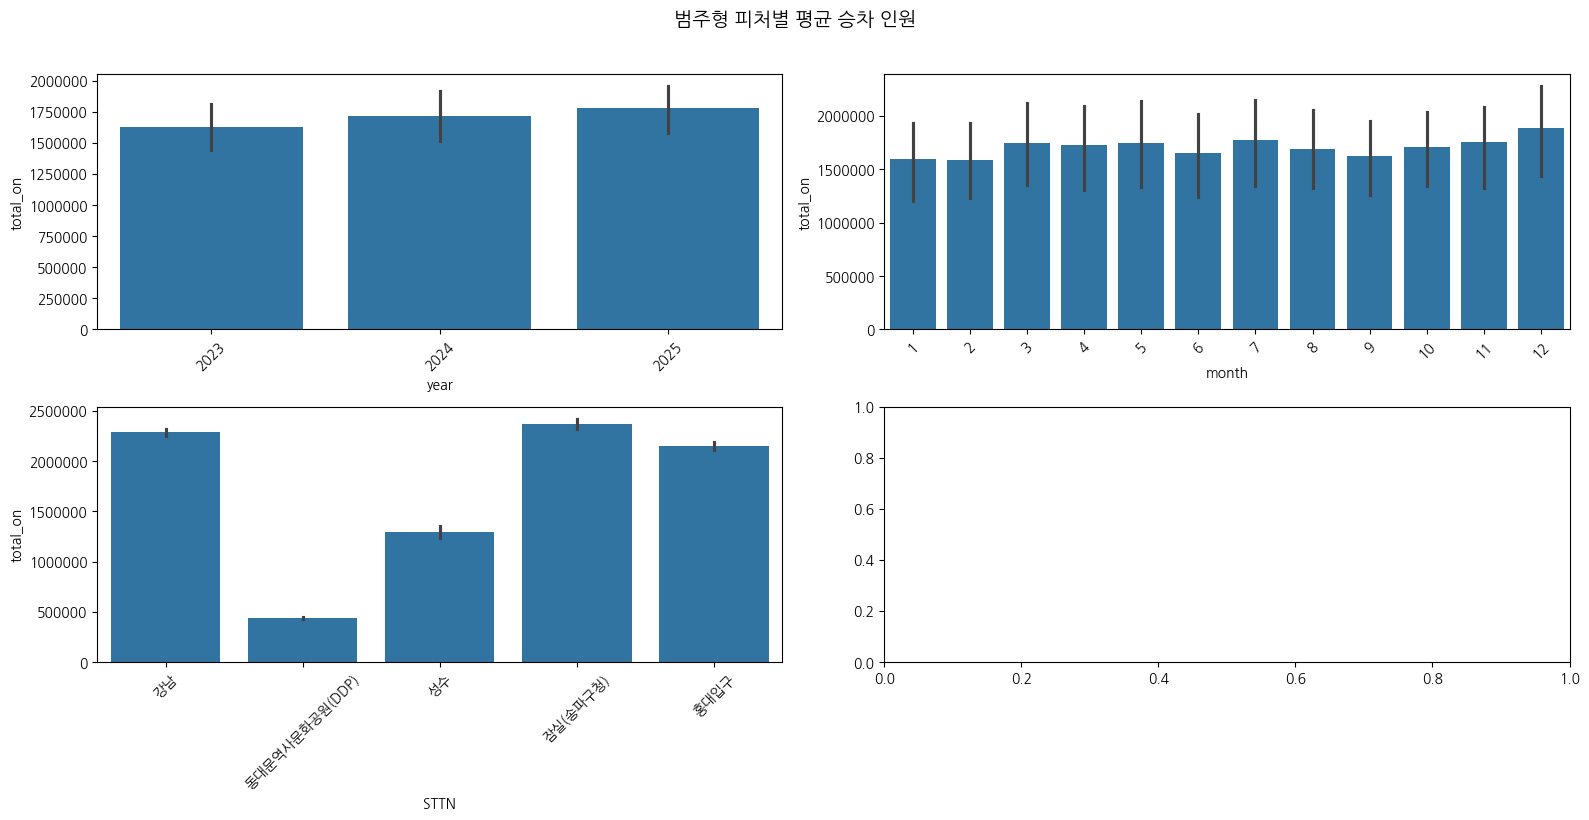

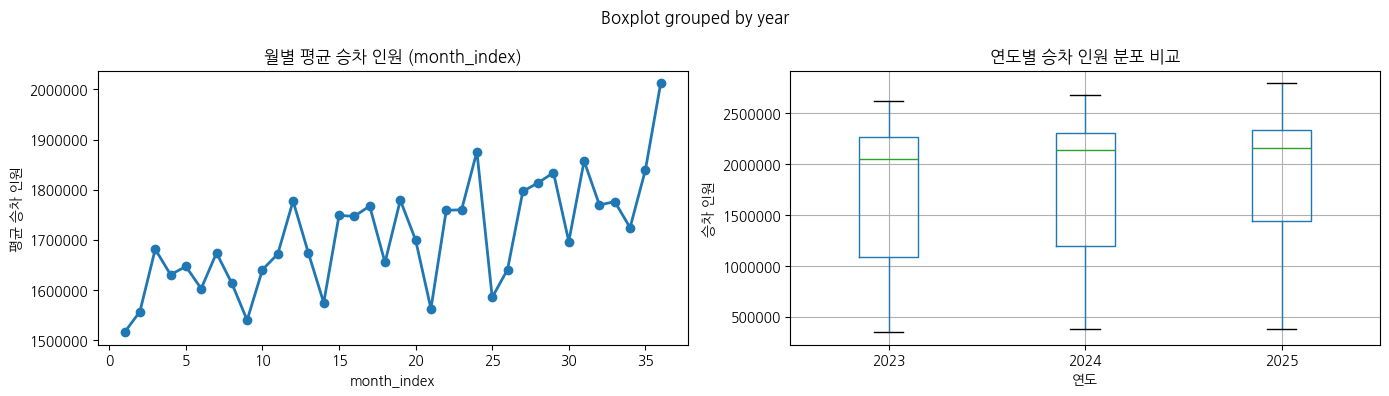

연도별 평균 승차 인원:
year
2023    1629377.6
2024    1716929.6
2025    1778862.7
Name: total_on, dtype: float64


In [ ]:
# 그래프 틀 만들기 figsize=16, 8 전체 크기 ncols = 2 열 2개 nrows = 2 행 2개
fig, axs = plt.subplots(figsize=(16, 8), ncols=2, nrows=2)

# 범주형 피처 목록
cat_features = ['year', 'month', 'STTN']

for i, feature in enumerate(cat_features):
    row = i // 2
    col = i % 2
    sns.barplot(x=feature, y='total_on', data=df_5, ax=axs[row, col])
    axs[row, col].tick_params(axis='x', rotation=45)
    axs[row, col].ticklabel_format(style='plain', axis='y') # 수치가 간략화 안되고 원본 데이터 보는 방법 (1e6이 아닌 전체 수치)

plt.suptitle('범주형 피처별 평균 승차 인원', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(figsize=(14, 4), ncols=2)

monthly_avg = df_5.groupby('month_index')['total_on'].mean()
axes[0].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2)
axes[0].set_title('월별 평균 승차 인원 (month_index)')
axes[0].set_xlabel('month_index')
axes[0].set_ylabel('평균 승차 인원')
axes[0].ticklabel_format(style='plain', axis='y')

df_5.boxplot(column='total_on', by='year', ax=axes[1])
axes[1].set_title('연도별 승차 인원 분포 비교')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('승차 인원')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

print('연도별 평균 승차 인원:')
print(df_5.groupby('year')['total_on'].mean().round(1))



In [ ]:
print(df_5.groupby('year')['total_on'].mean())

year
2023    1.629378e+06
2024    1.716930e+06
2025    1.778863e+06
Name: total_on, dtype: float64


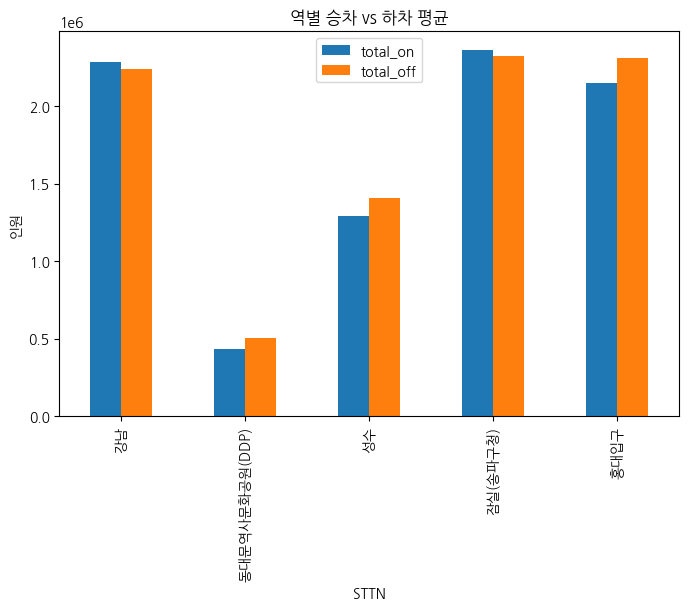

In [ ]:
df_avg = df_5.groupby('STTN')[['total_on', 'total_off']].mean()

df_avg.plot(kind='bar', figsize=(8,5))
plt.title('역별 승차 vs 하차 평균')
plt.ylabel('인원')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# 평가 지표 함수 정의 (RMSLE, RMSE, MAE)
# RMSLE (Root Mean Squared Log Error)
# 로그 스케일에서 오차를 측정하므로, 작은 값과 큰 값의 '상대적 오차'를 동등하게 평가
# '50% 틀렸다'는 것을 실제 값 크기에 관계없이 유사하게 패널티 부여
def rmsle(y, pred):
  log_y = np.log1p(y)
  log_pred = np.log1p(pred)
  squared_error = (log_y - log_pred) ** 2
  rmsle = np.sqrt(np.mean(squared_error))
  return rmsle

# RMSE (Root Mean Squared Error)
def rmse(y, pred):
  return np.sqrt(mean_squared_error(y, pred))
# 큰 오차를 제곱으로 더 크게 벌주므로 이상치에 민감, 원본 단위(대여 횟수)로 해석 가능

# 세 평가지표를 한 번에 출력
def evaluate_regr(y, pred):
  rmsle_val = rmsle(y, pred)
  rmse_val = rmse(y, pred)
  mae_val = mean_absolute_error(y, pred) # MAE (Mean Absolute Error): 절대 오차의 평균, 이상치에 가장 덜 민감한 지표
  print('RMSLE: {0:.3f}, RMSE: {1:.3f}, MAE: {2:.3f}'.format(
      rmsle_val, rmse_val, mae_val
  ))


In [ ]:
# [Step 1] 시간순 80/20 분할 + 기본 LinearRegression -> baseline_code
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import make_scorer

# 시간순 정렬
df_5 = df_5.sort_values(['USE_MM', 'STTN']).reset_index(drop=True)

# 피처(X)와 타깃(y)분리
y_target = df_5['total_on']

X_features = df_5.drop(['total_on','total_on_log', 'SBWY_ROUT_LN_NM', 'USE_MM'], axis=1)
X_features = pd.get_dummies(X_features, columns=['STTN'], drop_first=True)

# 시계열 데이터 분할: 시간 순서대로 80 : 20
split_idx = int(len(X_features) * 0.8)

X_train_full = X_features.iloc[:split_idx]
X_test = X_features.iloc[split_idx:]
y_train_full = y_target.iloc[:split_idx]
y_test = y_target.iloc[split_idx:]

print(f'전체 데이터 : {len(X_features)}행')
print(f'훈련셋 (80%) : {len(X_train_full)}행')
print(f'테스트셋(20%): {len(X_test)}행')

print('훈련셋 연도 분포:')
print(df_5.iloc[:split_idx]['year'].value_counts().sort_index())

print('테스트셋 연도 분포:')
print(df_5.iloc[split_idx:]['year'].value_counts().sort_index())

전체 데이터 : 180행
훈련셋 (80%) : 144행
테스트셋(20%): 36행
훈련셋 연도 분포:
year
2023    48
2024    48
2025    48
Name: count, dtype: int64
테스트셋 연도 분포:
year
2023    12
2024    12
2025    12
Name: count, dtype: int64
